<a href="https://colab.research.google.com/github/samiamridula1/CSE220_practice_with_solve/blob/main/cse428.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
import cv2
from PIL import Image
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
from torchvision import transforms as T
from torchvision.transforms import InterpolationMode
from sklearn.metrics import (accuracy_score,precision_recall_fscore_support,classification_report,confusion_matrix)

In [ ]:
import os

# Define the base directory where the dataset was unzipped
base_data_dir = '/content'

# Verify that the 'Training' directory exists and list its subdirectories to get class names.
train_dir = os.path.join(base_data_dir, 'Training')
if not os.path.exists(train_dir):
    raise FileNotFoundError(f"Training directory not found at {train_dir}. Please ensure the dataset is unzipped correctly.")

class_names = sorted(os.listdir(train_dir))
num_classes = len(class_names)
print(f"Classes: {class_names}")
print(f"Number of classes: {num_classes}")


Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Number of classes: 4


In [ ]:
#load the dataset through kaggle api
! kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset --unzip

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 157M/157M [00:07<00:00, 20.9MB/s]



In [ ]:
def get_class_paths(path):
  classes=[]
  class_paths=[]
  for label in os.listdir(path):
    label_path=os.path.join(path,label)
    if os.path.isdir(label_path):
      for image in os.listdir(label_path):
        image_path=os.path.join(label_path,image)
        #add class and path to resprective lists
        classes.append(label)
        class_paths.append(image_path)
  #create a dataframe with the collected data
  #classes will store the labels or categories of the images (e.g., "glioma," "meningioma").
  #class_paths will store the full file paths to each image.
  df=pd.DataFrame({
      "Class Path": class_paths,
      "Class":classes
  })
  return df


In [ ]:
#training dataframe
tr_df= get_class_paths("/content/Training")

In [ ]:
tr_df

,Class Path,Class
0,/content/Training/glioma/Tr-gl_300.jpg,glioma
1,/content/Training/glioma/Tr-gl_783.jpg,glioma
2,/content/Training/glioma/Tr-gl_1305.jpg,glioma
3,/content/Training/glioma/Tr-gl_481.jpg,glioma
4,/content/Training/glioma/Tr-gl_661.jpg,glioma
...,...,...
5595,/content/Training/notumor/Tr-no_1139.jpg,notumor
5596,/content/Training/notumor/Tr-no_1356.jpg,notumor
5597,/content/Training/notumor/Tr-no_136.jpg,notumor
5598,/content/Training/notumor/Tr-no_931.jpg,notumor


In [ ]:
#testing dataframe
ts_df= get_class_paths("/content/Testing")

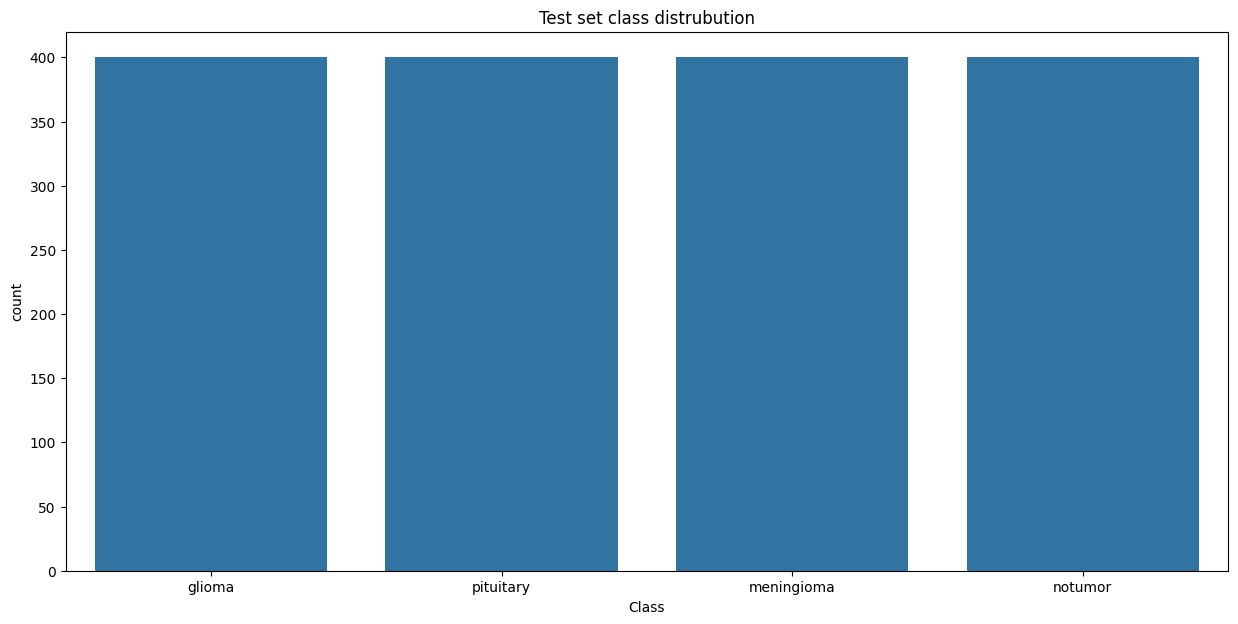

In [ ]:
plt.figure(figsize=(15,7))
plt.title('Test set class distrubution')
ax=sns.countplot(data=ts_df,x=ts_df["Class"])
#fairly balanced testing set

In [1]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define image transformations and data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255, # Normalize pixel values to [0, 1]
    rotation_range=20,
    width_shift_range=0.2, # Corrected argument name
    height_shift_range=0.2, # Corrected argument name
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2 # Use 20% of data for validation
)

# Data generator for training data
img_size = (224, 224)
batch_size = 32

tr_gen = train_datagen.flow_from_dataframe(
    dataframe=tr_df,
    x_col="Class Path",
    y_col="Class",
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    subset='training',
    seed=42
)

# Data generator for validation data
valid_gen = train_datagen.flow_from_dataframe(
    dataframe=tr_df,
    x_col="Class Path",
    y_col="Class",
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    subset='validation',
    seed=42
)

# Data generator for test data (only rescaling, no augmentation)
test_datagen = ImageDataGenerator(
    rescale=1./255
)

ts_gen = test_datagen.flow_from_dataframe(
    dataframe=ts_df,
    x_col="Class Path",
    y_col="Class",
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False, # Important for evaluation and confusion matrix
    seed=42
)

# Display some sample augmented images from the training generator
plt.figure(figsize=(20,20))
for i in range(16):
  plt.subplot(4,4,i+1)
  batch = next(tr_gen)
  image = batch[0][0]
  label = batch[1][0]
  plt.imshow(image)
  class_index = np.argmax(label)
  class_name = class_names[class_index] # Use the global class_names
  plt.title(f"Label: {class_name}")
  plt.axis('off')
plt.tight_layout()
plt.show()


NameError: name 'tr_df' is not defined

In [ ]:
class TumorClassifierHead(nn.Module):
    def __init__(self,encoder_channels=1024,num_tumor_classes=4,reduced_channels=None,dropout_rate=0.3):
        super().__init__()

        if reduced_channels is None:
            reduced_channels = encoder_channels // 2

        self.conv_block1 = nn.Conv2d(encoder_channels, reduced_channels, kernel_size=3, padding=1)
        self.bn_block1 = nn.BatchNorm2d(reduced_channels)

        self.conv_block2 = nn.Conv2d(reduced_channels, reduced_channels // 2, kernel_size=3, padding=1)
        self.bn_block2 = nn.BatchNorm2d(reduced_channels // 2)

        self.conv_block3 = nn.Conv2d(reduced_channels // 2, num_tumor_classes, kernel_size=3, padding=1)

        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, features):
        x = F.relu(self.bn_block1(self.conv_block1(features)))
        x = F.relu(self.bn_block2(self.conv_block2(x)))
        x = self.conv_block3(x)

        x = self.global_pool(x)
        x = x.squeeze(-1).squeeze(-1)
        x = self.dropout(x)

        return x


In [ ]:
#plot the graps for visulazation
#get training and validation metrics from history
metrics=['accuracy','loss','precision','recall']#storing in training and validation data
tr_metrics = { m: cnn_hist.history[m] for m in metrics}
val_metrics = { m: cnn_hist.history[f'val_{m}'] for m in metrics}

#find best epochs and values
best_epochs ={}
best_values ={}
for m in metrics:
  if m=='loss': #we find the lowest loss in our training history,this is when our model was most accurate
    idx = np.argmin(val_metrics[m])
  else:
    idx = np.argmax(val_metrics[m])
  #tracking in which epochs did the model has lowest loss
  best_epochs[m]=idx+1
  best_values[m]=val_metrics[m][idx]


#plot metrics
plt.figure(figsize=(20,12))
plt.style.use('fivethirtyeight')
for i,metric in enumerate(metrics,1):
  plt.subplot(2,2,i)
  epochs = range(1, len(tr_metrics[metric]) +1)
  plt.plot(epochs,tr_metrics[metric], 'r',label=f'Training {metric}')
  plt.plot(epochs,val_metrics[metric],'g',label=f'Validation {metric}')
  plt.scatter(best_epochs[metric],best_values[metric],s=150,c='blue',label=f'Best epochs ={best_epochs[metric]}')
  plt.title(f'Training and Validation {metric}')
  plt.xlabel('Epochs')
  plt.ylabel(metric.title())
  plt.legend()
  plt.grid(True)
plt.suptitle('Model training metrics over epochs')
plt.show()

In [ ]:
#training ,validation and testing
train_score = model.evaluate(tr_gen,verbose=1)#evaluating model with the same data
valid_score = model.evaluate(valid_gen,verbose=1)
test_score = model.evaluate(ts_gen,verbose=1)

print(f'Training accuracy: {train_score[1]*100:.2f}%')
print(f'Train loss: {train_score[0]:.4f}')
print(f'Validation accuracy: {valid_score[1]*100:.2f}%')
print(f'Validation loss: {valid_score[0]:.4f}')
print(f'Test accuracy: {test_score[1]*100:.2f}%')
print(f'Test loss: {test_score[0]:.4f}')

# how well the trained model performs on different datasets,
# providing insights into its ability to generalize to unseen data (testing set) and
# whether it might be overfitting
#(if training accuracy is much higher than validation accuracy).

In [ ]:
epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(20, 4))

plt.subplot(1, 4, 1)
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 4, 2)
plt.plot(epochs, history["train_dice"], label="Train Dice")
plt.plot(epochs, history["val_dice"], label="Val Dice")
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.title("Dice Coefficient")
plt.legend()
plt.grid(True)

plt.subplot(1, 4, 3)
plt.plot(epochs, history["train_iou"], label="Train IoU")
plt.plot(epochs, history["val_iou"], label="Val IoU")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.title("Intersection over Union")
plt.legend()
plt.grid(True)

plt.subplot(1, 4, 4)
plt.plot(epochs, history["train_class_acc"], label="Train Accuracy")
plt.plot(epochs, history["val_class_acc"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Classification Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


NameError: name 'history' is not defined

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

checkpoint_path = "unet_stats/best_checkpoint.pth"
assert os.path.exists(checkpoint_path)

checkpoint = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(checkpoint["model_state"])
model.to(device)
model.eval()
history = checkpoint.get("history", None)

print(f"Loaded best model from {checkpoint_path}")
print(f"Checkpoint epoch: {checkpoint.get('epoch')}")
print(full_train_dataset.classes)



In [ ]:
metrics = evaluate_multitask_model(
    model=model,
    data_loader=dataloaders["test"],
    device=device,
    class_labels=full_train_dataset.classes,
    show_per_class_metrics=True
)

print("\nFinal Test Metrics:")
print("Segmentation:")
for k, v in metrics["segmentation"].items():
    print(f"  {k}: {v:.4f}")

print("\nClassification:")
for k, v in metrics["classification"].items():
    if k != "per_class":
        print(f"  {k}: {v:.4f}")


In [ ]:
from PIL import Image

def predict(img_path:str) -> None:
  # Get class labels
  labels = list(class_dict.values())#DIFF TYPES OF TUMORS

  # Create figure
  plt.figure(figsize=(12,6))

  # Load and preprocess image
  img = Image.open(img_path)
  resized_img = img.resize((299,299))
  img_array = np.asarray(resized_img)
  img_array = np.expand_dims(img_array, axis=0) / 255.0

  # Get model predictions
  predictions = model.predict(img_array)
  probabilities = list(predictions[0])

  # Get predicted classes
  predicted_class_idx = np.argmax(probabilities)
  predicted_class = class_dict[predicted_class_idx]

  # Plot original image
  plt.subplot(1, 2, 1)
  plt.imshow(resized_img)
  plt.title(f"Input MRI Image\nPredicted: {predicted_class}")

  # Plot prediction probabilities
  plt.subplot(1,2, 2)
  bars = plt.barh(labels, probabilities)
  plt.xlabel("Probability", fontsize=15)
  plt.title("Class Probabilities")

  # Add probability labels to bars
  ax = plt.gca()
  ax.bar_label(bars, fmt='%.2f')

  plt.tight_layout()
  plt.show()

  print(f"\nPredicted tumor type: {predicted_class}")


In [ ]:
predict('/content/Testing/meningioma/Te-meTr_0005.jpg')


In [ ]:
model.save_weights("xception_model.weights.h5")


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, BatchNormalization, MaxPooling2D, Dropout, Flatten, Dense
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras import regularizers

# Create a Sequential model
cnn_model = Sequential()

#4 convolutional blocks
#Convolutional Block 1

# convolution layer with 512 filters-to export features
cnn_model.add(Conv2D(512, (3, 3), padding='same', activation='relu', input_shape=(224,224, 3)))
cnn_model.add(BatchNormalization())
# max pooling layer
cnn_model.add(MaxPooling2D((2, 2)))

#Convolutional Block 2

# convolution layer with 256 filters
cnn_model.add(Conv2D(256, (3, 3), padding='same', activation='relu'))
cnn_model.add(BatchNormalization())
cnn_model.add(Conv2D(256, (3, 3), padding='same', activation='relu'))
cnn_model.add(BatchNormalization())
# max pooling layer
cnn_model.add(MaxPooling2D((2, 2)))
# drop 25% of units
cnn_model.add(Dropout(0.25))

#Convolutional Block 3
# convolution layer with 128 filters
cnn_model.add(Conv2D(128, (3, 3), padding='same', activation='relu'))
cnn_model.add(BatchNormalization())
cnn_model.add(Conv2D(128, (3, 3), padding='same', activation='relu'))
cnn_model.add(BatchNormalization())
# max pooling layer
cnn_model.add(MaxPooling2D((2, 2)))
# drop 25% of units
cnn_model.add(Dropout(0.25))

## Convolutional Block 4

# conv layer with 64 filters
cnn_model.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
cnn_model.add(BatchNormalization())
cnn_model.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
cnn_model.add(BatchNormalization())
# max pooling layer
cnn_model.add(MaxPooling2D((2, 2)))

## Fully connected layers

# Flatten Layer to 1D
cnn_model.add(Flatten())


# Dense layer 1
cnn_model.add(Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01)))
# drop 35% of units
cnn_model.add(Dropout(0.35))
# Output dense layer
cnn_model.add(Dense(num_classes, activation='softmax')) # Use dynamically determined num_classes

# compile model
cnn_model.compile(Adamax(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy', 'precision', 'recall'])

# show model summary
cnn_model.summary()


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 512)  │        14,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 512)  │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 512)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 256)  │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 256)  │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 256)  │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 256)  │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 56, 56, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 56, 56, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 5,555,844 (21.19 MB)

 Trainable params: 5,553,028 (21.18 MB)

 Non-trainable params: 2,816 (11.00 KB)

In [ ]:
#Visualize CNN metrics while training
# Get training and validation metrics from history
metrics = ['accuracy', 'loss', 'precision', 'recall']
tr_metrics = {m: cnn_hist.history[m] for m in metrics}
val_metrics = {m: cnn_hist.history[f'val_{m}'] for m in metrics}

# Find best epochs and values on validation set
best_epochs = {}
best_values = {}

for m in metrics:
  # less is better when it comes to loss
  if m == 'loss':
    idx = np.argmin(val_metrics[m])
  # more is better for other metrics
  else:
    idx = np.argmax(val_metrics[m])
  best_epochs[m] = idx + 1
  best_values[m] = val_metrics[m][idx]

# Plot metricies
plt.figure(figsize=(20,12))
plt.style.use('fivethirtyeight')

for i, metric in enumerate(metrics, 1):
  plt.subplot(2, 2, i)
  epochs = range(1, len(val_metrics[metric])+ 1)

  plt.plot(epochs, tr_metrics[metric], 'r', label=f'Training {metric}')
  plt.plot(epochs, val_metrics[metric], 'g', label=f'Validation {metric}')
  plt.scatter(best_epochs[metric], best_values[metric], s=150, c='blue',
              label=f'Best epoch = {best_epochs[metric]}')

  plt.title(f'Training and Validation {metric.title()}')
  plt.xlabel('Epochs')
  plt.ylabel(metric.title())
  plt.legend()
  plt.grid(True)

plt.suptitle("Model Training Metrics over epochs", fontsize=16)
plt.show()


In [ ]:
print(f'Train Accuracy: {cnn_train_score[1]*100:.2f}%')
print(f'Train Loss: {cnn_train_score[0]:.4f}')

print(f'\nValid Accuracy: {cnn_valid_score[1]*100:.2f}%')
print(f'Valid Loss: {cnn_valid_score[0]:.4f}') # Corrected label from 'Accuracy' to 'Loss'

print(f'\nTest Accuracy: {cnn_test_score[1]*100:.2f}%')
print(f'Test Loss: {cnn_test_score[0]:.4f}')

In [ ]:
#Confusion Matrix

# Display Confusion Matrix
cm = confusion_matrix(y_true, y_pred) # Use y_true and y_pred
# map predictions to labels
labels = [idx_to_class[i] for i in range(len(idx_to_class))] # Dynamically get labels
plt.figure(figsize=(9,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.yticks(rotation=90)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.show()


In [ ]:
from PIL import Image

def predict(img_path:str) -> None:
  # Get class labels using the globally defined mapping
  labels = [idx_to_class[i] for i in sorted(idx_to_class.keys())]

  # Create figure
  plt.figure(figsize=(12,6))

  # Load and preprocess image
  img = Image.open(img_path)
  resized_img = img.resize((224,224))
  img_array = np.asarray(resized_img)
  img_array = np.expand_dims(img_array, axis=0) / 255.0

  # Get model predictions
  predictions = cnn_model.predict(img_array)
  probabilities = list(predictions[0])

  # Get predicted classes
  predicted_class_idx = np.argmax(probabilities)
  predicted_class = idx_to_class[predicted_class_idx] # Use idx_to_class

  # Plot original image
  plt.subplot(1, 2, 1)
  plt.imshow(resized_img)
  plt.title(f"Input MRI Image\nPredicted: {predicted_class}")

  # Plot prediction probabilities
  plt.subplot(1, 2, 2)
  bars = plt.barh(labels, probabilities)
  plt.xlabel("Probability", fontsize=15)
  plt.title("Class Probabilities")

  # Add probability labels to bars
  ax = plt.gca()
  ax.bar_label(bars, fmt='%.2f')

  plt.tight_layout()
  plt.show()

  print(f"\nPredicted tumor type: {predicted_class}")


In [ ]:
predict('/content/Testing/meningioma/Te-meTr_0005.jpg')

NameError: name 'predict' is not defined